In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist   #digitos manuscritos

In [3]:
(x_train, y_train),(x_test, y_test)= fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(x_train.shape)
print(x_test.shape)
print(len(y_train)+len(y_test))

(60000, 28, 28)
(10000, 28, 28)
70000


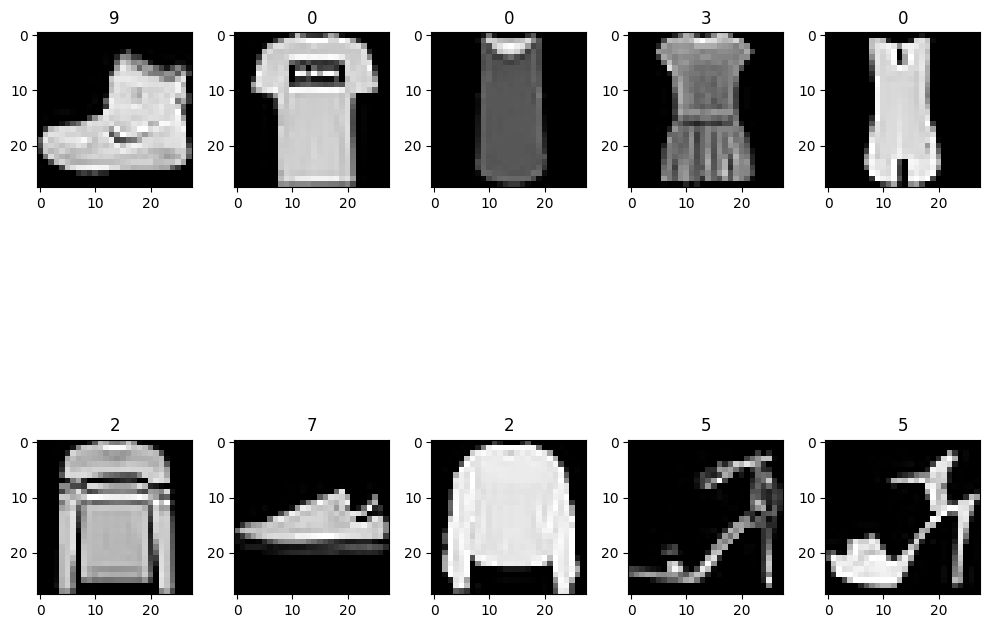

In [14]:
plt.figure(figsize=(10,10))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(y_train[i])
plt.tight_layout()

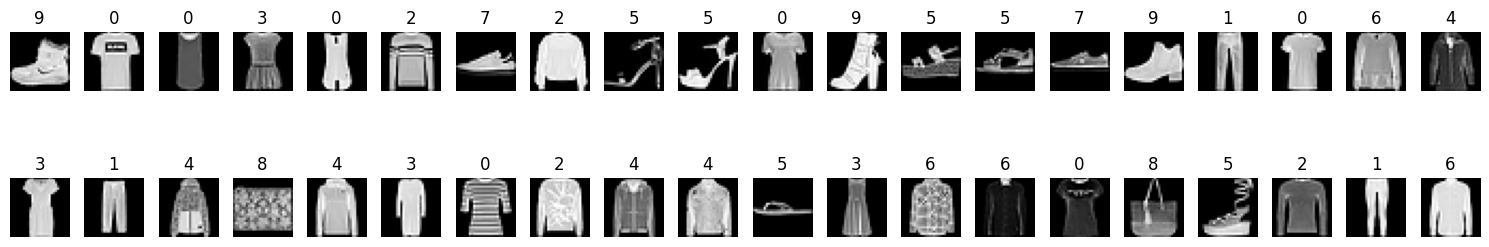

In [27]:
plt.figure(figsize=(15, 6))
for i in range(40):              # ← 20 imágenes
    plt.subplot(4, 20, i+1)      # 2 filas × 10 columnas
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
x_train= x_train/255.0
x_test= x_test/255.0

In [7]:
model= tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #APLANAMOS LA IMAGEN (SE CONVIERTE EN UN VECTOR PLANO DE NÚMEROS)
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [9]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5032
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3769
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3377
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3145
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2955
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2829
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2680
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2581
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2486
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2409


Forma de la muestra (1, 28, 28)
Etiqueta real de la muestra 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicción de la RNA (Probabilidades)
 [[5.99757925e-07 1.38698042e-09 2.31102817e-08 6.46679297e-08
  1.08112246e-07 8.04030265e-07 8.71125485e-06 3.89660181e-06
  9.99985218e-01 6.35034780e-07]]
Predicción afinada la de RNA [8]


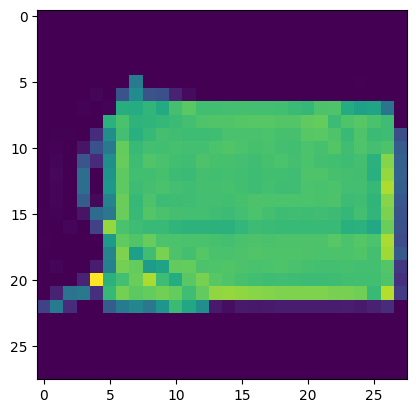

In [26]:
muestra= x_test[18].reshape(1 ,28,28) #La muestra es un lote de una imagen de 28 por 28
print('Forma de la muestra', muestra.shape)
print('Etiqueta real de la muestra', y_test[1])
prediccion= model.predict(muestra)
print('Predicción de la RNA (Probabilidades)\n', prediccion)
print('Predicción afinada la de RNA', prediccion.argmax(1))
plt.imshow(muestra.reshape(28,28))